In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

In [2]:
from google.colab import files

uploaded = files.upload()

Saving international-international-friendlies-teams-2026-to-2026-stats.csv to international-international-friendlies-teams-2026-to-2026-stats.csv


In [3]:
df= pd.read_csv('international-international-friendlies-teams-2026-to-2026-stats.csv')

In [4]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179 entries, 0 to 178
Columns: 293 entries, team_name to over145_corners_percentage
dtypes: float64(36), int64(254), object(3)
memory usage: 409.9+ KB


,team_name,common_name,season,country,matches_played,matches_played_home,matches_played_away,suspended_matches,wins,wins_home,...,goals_conceded_min_61_to_70,goals_conceded_min_71_to_80,goals_conceded_min_81_to_90,draw_percentage_overall,draw_percentage_home,draw_percentage_away,loss_percentage_ovearll,loss_percentage_home,loss_percentage_away,over145_corners_percentage
0,Finland National Team,Finland,2026,Finland,3,0,3,0,1,0,...,2,0,0,33,0,33,33,0,33,0
1,Switzerland National Team,Switzerland,2026,Switzerland,3,2,1,0,1,1,...,1,0,1,33,0,100,33,50,0,0
2,Portugal National Team,Portugal,2026,Portugal,2,0,2,0,1,0,...,0,0,0,50,0,50,0,0,0,0
3,Norway National Team,Norway,2026,Norway,3,2,1,0,1,1,...,0,1,0,33,50,0,33,0,100,0
4,Germany National Team,Germany,2026,Germany,3,2,1,0,3,2,...,1,1,0,0,0,0,0,0,0,0


In [5]:
df.isnull().sum()

,0
team_name,0
common_name,0
season,0
country,0
matches_played,0
...,...
draw_percentage_away,0
loss_percentage_ovearll,0
loss_percentage_home,0
loss_percentage_away,0


In [6]:
df.duplicated().sum()

np.int64(0)

# Business Question

Which international teams are the most dangerous attacking sides, and what drives their attacking success?

Step 1: Define Attack Intelligence Components

Rather than using goals alone, we'll measure attack from four dimensions:
| Component         | Metric                 | Weight |
| ----------------- | ---------------------- | ------ |
| Goal Production   | goals_scored_per_match | 40%    |
| Chance Creation   | shots_on_target        | 25%    |
| Attacking Control | average_possession     | 15%    |
| Chance Quality    | xg_for_avg_overall     | 20%    |

Formula:

AII=0.40(GPM)+0.25(SOT)+0.15(POS)+0.20(XG)


In [7]:
df["shots_on_target_per_match"] = (
    df["shots_on_target"] /
    df["matches_played"]
)

In [8]:
df["shots_per_match"] = (
    df["shots"] /
    df["matches_played"]
)

# Step 2: Create the Index

In [9]:
from sklearn.preprocessing import MinMaxScaler

attack_metrics = [
    "goals_scored_per_match",
    "shots_on_target",
    "average_possession",
    "xg_for_avg_overall"
]

scaler = MinMaxScaler()

attack_scaled = pd.DataFrame(
    scaler.fit_transform(df[attack_metrics]),
    columns=attack_metrics
)

df["Attack_Intelligence_Index"] = (
    attack_scaled["goals_scored_per_match"] * 0.40 +
    attack_scaled["shots_on_target"] * 0.25 +
    attack_scaled["average_possession"] * 0.15 +
    attack_scaled["xg_for_avg_overall"] * 0.20
) * 100

# Step 3: Rank Teams

In [10]:
attack_rankings = (
    df[["common_name","Attack_Intelligence_Index"]]
    .sort_values("Attack_Intelligence_Index", ascending=False)
)

attack_rankings.head(20)

,common_name,Attack_Intelligence_Index
4,Germany,77.780627
67,Bulgaria,69.953916
166,Philippines,68.622816
97,Tanzania,65.380716
9,Brazil,64.319856
105,Aruba,62.518694
163,Gibraltar,57.681641
156,Singapore,56.479044
66,Morocco,56.432097
150,Turkey,55.753453


# Which teams are overperforming offensively relative to their competitive level?

In [13]:
attack_rankings = (
    df[
        [
            "common_name",
            "goals_scored_per_match",
            "xg_for_avg_overall",
            "shots_on_target",
            "average_possession",
            "Attack_Intelligence_Index"
        ]
    ]
    .sort_values("Attack_Intelligence_Index", ascending=False)
)

attack_rankings.head(20)

,common_name,goals_scored_per_match,xg_for_avg_overall,shots_on_target,average_possession,Attack_Intelligence_Index
4,Germany,3.33,2.61,27,63,77.780627
67,Bulgaria,3.67,1.86,26,37,69.953916
166,Philippines,5.00,1.22,11,66,68.622816
97,Tanzania,3.00,2.75,12,71,65.380716
9,Brazil,3.33,1.52,23,49,64.319856
105,Aruba,4.00,1.42,14,54,62.518694
163,Gibraltar,4.00,1.40,9,50,57.681641
156,Singapore,4.00,0.94,9,63,56.479044
66,Morocco,3.00,1.28,16,62,56.432097
150,Turkey,4.00,1.13,7,60,55.753453


In [54]:
attack_rankings = qualified[
    [
        "common_name",
        "matches_played",
        "Attack_Intelligence_Index"
    ]
].sort_values(
    "Attack_Intelligence_Index",
    ascending=False
)

attack_rankings.to_csv(
    "attack_intelligence_rankings.csv",
    index=False
)

In [55]:
from google.colab import files

attack_rankings.to_csv(
    "attack_intelligence_rankings.csv",
    index=False
)

files.download(
    "attack_intelligence_rankings.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
top_surprises = attack_rankings.head(20)

surprise_teams = [
    "Bulgaria",
    "Philippines",
    "Tanzania",
    "Aruba",
    "Gibraltar",
    "Singapore"
]

df[df["common_name"].isin(surprise_teams)]

,team_name,common_name,season,country,matches_played,matches_played_home,matches_played_away,suspended_matches,wins,wins_home,...,draw_percentage_overall,draw_percentage_home,draw_percentage_away,loss_percentage_ovearll,loss_percentage_home,loss_percentage_away,over145_corners_percentage,shots_on_target_per_match,shots_per_match,Attack_Intelligence_Index
67,Bulgaria National Team,Bulgaria,2026,Bulgaria,3,1,2,0,2,0,...,0,0,0,33,100,0,0,8.666667,14.333333,69.953916
97,Tanzania National Team,Tanzania,2026,Tanzania,2,1,1,0,1,0,...,0,0,0,50,100,0,0,6.000000,20.500000,65.380716
105,Aruba,Aruba,2026,Aruba,2,2,0,0,2,2,...,0,0,0,0,0,0,0,7.000000,12.500000,62.518694
156,Singapore National Team,Singapore,2026,Singapore,1,1,0,0,1,1,...,0,0,0,0,0,0,0,9.000000,14.000000,56.479044
163,Gibraltar National Team,Gibraltar,2026,Gibraltar,1,1,0,0,1,1,...,0,0,0,0,0,0,0,9.000000,18.000000,57.681641
166,Philippines National Team,Philippines,2026,Philippines,1,1,0,0,1,1,...,0,0,0,0,0,0,0,11.000000,17.000000,68.622816


In [17]:
qualified_teams = df[df["matches_played"] >= 3]

In [18]:
attack_rankings = (
    qualified_teams[
        ["common_name", "matches_played", "Attack_Intelligence_Index"]
    ]
    .sort_values("Attack_Intelligence_Index", ascending=False)
)

attack_rankings.head(20)

,common_name,matches_played,Attack_Intelligence_Index
4,Germany,3,77.780627
67,Bulgaria,3,69.953916
9,Brazil,3,64.319856
66,Morocco,4,56.432097
11,Mexico,7,55.469570
60,Republic of Ireland,3,54.867694
18,Senegal,3,53.329955
45,South Korea,4,51.413864
13,Belgium,3,49.666223
1,Switzerland,3,49.362291


In [19]:
df[
    [
        "common_name",
        "matches_played",
        "shots",
        "shots_on_target",
        "goals_scored_per_match",
        "xg_for_avg_overall"
    ]
].sort_values(
    "shots_on_target",
    ascending=False
).head(15)

,common_name,matches_played,shots,shots_on_target,goals_scored_per_match,xg_for_avg_overall
11,Mexico,7,82,31,1.43,1.37
4,Germany,3,67,27,3.33,2.61
67,Bulgaria,3,43,26,3.67,1.86
9,Brazil,3,50,23,3.33,1.52
45,South Korea,4,56,22,1.50,1.62
26,Canada,4,53,22,1.25,1.32
20,Panama,6,43,21,1.67,1.05
60,Republic of Ireland,3,63,20,2.00,1.88
41,Scotland,3,40,18,1.33,1.18
33,Spain,3,52,18,1.33,1.73


In [20]:
df[
    ["common_name",
     "matches_played",
     "goals_scored",
     "shots",
     "shots_on_target",
     "xg_for_avg_overall"]
].sort_values(
    "goals_scored",
    ascending=False
).head(15)

,common_name,matches_played,goals_scored,shots,shots_on_target,xg_for_avg_overall
66,Morocco,4,12,38,16,1.28
67,Bulgaria,3,11,43,26,1.86
11,Mexico,7,10,82,31,1.37
20,Panama,6,10,43,21,1.05
4,Germany,3,10,67,27,2.61
9,Brazil,3,10,50,23,1.52
80,Iran,3,9,3,1,0.00
81,Nigeria,4,8,25,15,1.04
13,Belgium,3,8,34,16,1.03
92,Algeria,3,8,39,11,1.39


# Business Question #2

Which teams are overperforming or underperforming their expected goals (xG)?

# Step 1: Create Finishing Efficiency

In [21]:
qualified = df[df["matches_played"] >= 3].copy()

qualified["Finishing_Efficiency"] = (
    qualified["goals_scored_per_match"] /
    qualified["xg_for_avg_overall"]
)

# Step 2: Rank Teams

In [22]:
qualified = qualified[qualified["xg_for_avg_overall"] > 0]
qualified[
    [
        "common_name",
        "matches_played",
        "goals_scored_per_match",
        "xg_for_avg_overall",
        "Finishing_Efficiency"
    ]
].sort_values(
    "Finishing_Efficiency",
    ascending=False
).head(20)

,common_name,matches_played,goals_scored_per_match,xg_for_avg_overall,Finishing_Efficiency
7,Ivory Coast,3,2.33,0.74,3.148649
39,Austria,3,2.33,0.77,3.025974
13,Belgium,3,2.67,1.03,2.592233
66,Morocco,4,3.00,1.28,2.343750
120,British Virgin Islands,3,1.67,0.75,2.226667
9,Brazil,3,3.33,1.52,2.190789
62,Costa Rica,3,1.00,0.49,2.040816
42,Australia,3,2.00,0.99,2.020202
67,Bulgaria,3,3.67,1.86,1.973118
81,Nigeria,4,2.00,1.04,1.923077


In [56]:
finishing_efficiency = qualified[
    [
        "common_name",
        "matches_played",
        "goals_scored_per_match",
        "xg_for_avg_overall",
        "Finishing_Efficiency"
    ]
].sort_values(
    "Finishing_Efficiency",
    ascending=False
)

finishing_efficiency.to_csv(
    "finishing_efficiency.csv",
    index=False
)

In [57]:
finishing_efficiency.to_csv(
    "finishing_efficiency.csv",
    index=False
)

files.download(
    "finishing_efficiency.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Worst Finishers

In [25]:
qualified[
    [
        "common_name",
        "matches_played",
        "goals_scored_per_match",
        "xg_for_avg_overall",
        "Finishing_Efficiency"
    ]
].sort_values(
    "Finishing_Efficiency",
    ascending=True
).head(20)

,common_name,matches_played,goals_scored_per_match,xg_for_avg_overall,Finishing_Efficiency
29,Grenada,4,0.00,0.47,0.000000
134,FYR Macedonia,3,0.00,0.17,0.000000
68,Guinea,3,0.67,1.43,0.468531
59,Andorra,4,0.50,1.06,0.471698
51,Tunisia,3,0.33,0.69,0.478261
63,South Africa,3,0.67,1.40,0.478571
38,Serbia,3,0.67,1.37,0.489051
54,Greece,3,0.67,1.30,0.515385
106,Russia,3,1.00,1.69,0.591716
15,Japan,3,1.00,1.50,0.666667


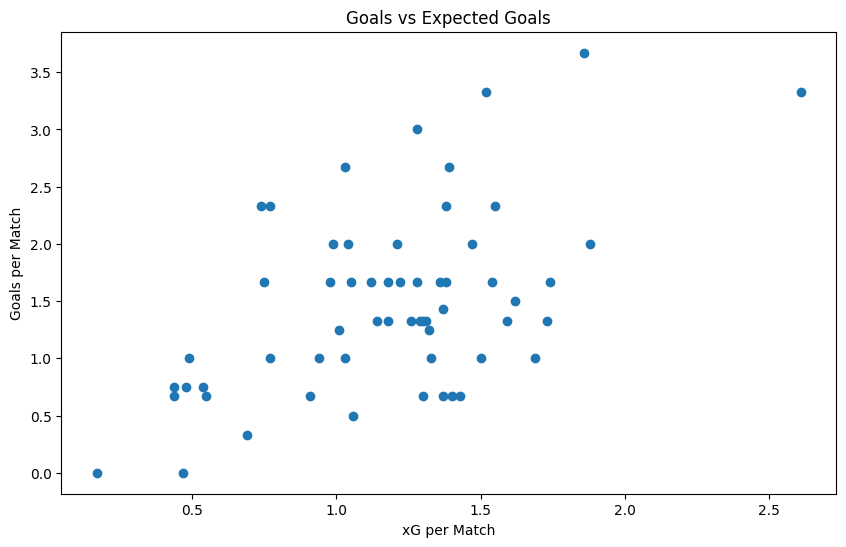

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    qualified["xg_for_avg_overall"],
    qualified["goals_scored_per_match"]
)

plt.xlabel("xG per Match")
plt.ylabel("Goals per Match")
plt.title("Goals vs Expected Goals")

plt.show()

# Business Question #3

Which teams have the strongest defensive foundations?

In [27]:
from sklearn.preprocessing import MinMaxScaler

defensive_metrics = [
    "goals_conceded_per_match",
    "xg_against_avg_overall",
    "clean_sheet_percentage",
    "minutes_per_goal_conceded"
]

scaled = pd.DataFrame(
    MinMaxScaler().fit_transform(
        qualified[defensive_metrics]
    ),
    columns=defensive_metrics,
    index=qualified.index
)

qualified["Defensive_DNA_Index"] = (
    (1 - scaled["goals_conceded_per_match"]) * 0.40 +
    (1 - scaled["xg_against_avg_overall"]) * 0.30 +
    scaled["clean_sheet_percentage"] * 0.20 +
    scaled["minutes_per_goal_conceded"] * 0.10
) * 100

In [28]:
print("qualified shape:", qualified.shape)

print(
    [col for col in qualified.columns
     if "defensive" in col.lower() or "dna" in col.lower()]
)

qualified shape: (59, 298)
['Defensive_DNA_Index']


In [29]:
qualified.columns[-20:]

Index(['goals_conceded_min_11_to_20', 'goals_conceded_min_21_to_30',
       'goals_conceded_min_31_to_40', 'goals_conceded_min_41_to_50',
       'goals_conceded_min_51_to_60', 'goals_conceded_min_61_to_70',
       'goals_conceded_min_71_to_80', 'goals_conceded_min_81_to_90',
       'draw_percentage_overall', 'draw_percentage_home',
       'draw_percentage_away', 'loss_percentage_ovearll',
       'loss_percentage_home', 'loss_percentage_away',
       'over145_corners_percentage', 'shots_on_target_per_match',
       'shots_per_match', 'Attack_Intelligence_Index', 'Finishing_Efficiency',
       'Defensive_DNA_Index'],
      dtype='object')

In [30]:
qualified[
    [
        "common_name",
        "matches_played",
        "goals_conceded_per_match",
        "xg_against_avg_overall",
        "clean_sheet_percentage",
        "minutes_per_goal_conceded",
        "Defensive_DNA_Index"
    ]
].sort_values(
    "Defensive_DNA_Index",
    ascending=False
).head(20)

,common_name,matches_played,goals_conceded_per_match,xg_against_avg_overall,clean_sheet_percentage,minutes_per_goal_conceded,Defensive_DNA_Index
60,Republic of Ireland,3,0.00,0.17,100,0,87.943548
11,Mexico,7,0.14,0.83,86,643,85.633792
33,Spain,3,0.33,0.09,67,273,82.960283
26,Canada,4,0.50,0.35,75,180,78.115916
39,Austria,3,0.33,0.64,67,273,76.307057
92,Algeria,3,0.00,1.18,100,0,75.725806
15,Japan,3,0.00,1.25,100,0,74.879032
132,Zimbabwe,4,0.50,0.84,75,180,72.188496
19,Bolivia,3,0.67,0.00,33,134,71.381529
7,Ivory Coast,3,0.33,1.05,67,273,71.347380


In [58]:
defensive_dna = qualified[
    [
        "common_name",
        "matches_played",
        "Defensive_DNA_Index"
    ]
].sort_values(
    "Defensive_DNA_Index",
    ascending=False
)

defensive_dna.to_csv(
    "defensive_dna_rankings.csv",
    index=False
)

In [59]:
defensive_dna.to_csv(
    "defensive_dna_rankings.csv",
    index=False
)

files.download(
    "defensive_dna_rankings.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Question A

Which teams are hardest to score against?

In [33]:
qualified[
    [
        "common_name",
        "goals_conceded_per_match",
        "clean_sheet_percentage"
    ]
].sort_values(
    "goals_conceded_per_match"
)

,common_name,goals_conceded_per_match,clean_sheet_percentage
15,Japan,0.00,100
35,Egypt,0.00,100
92,Algeria,0.00,100
60,Republic of Ireland,0.00,100
11,Mexico,0.14,86
39,Austria,0.33,67
33,Spain,0.33,67
7,Ivory Coast,0.33,67
51,Tunisia,0.33,67
66,Morocco,0.50,50


# Question B

Which teams allow the fewest quality chances?

In [34]:
qualified[
    [
        "common_name",
        "xg_against_avg_overall"
    ]
].sort_values(
    "xg_against_avg_overall"
)

,common_name,xg_against_avg_overall
19,Bolivia,0.00
63,South Africa,0.00
33,Spain,0.09
60,Republic of Ireland,0.17
26,Canada,0.35
66,Morocco,0.53
96,Kenya,0.63
39,Austria,0.64
49,Haiti,0.68
4,Germany,0.71


# Question C

Which teams are outperforming defensively?

In [35]:
qualified["Defensive_Efficiency"] = (
    qualified["xg_against_avg_overall"] /
    qualified["goals_conceded_per_match"]
)

# Business Question #4

Which teams are balanced contenders, attack specialists, or defense specialists?

Build a World Cup Readiness Score (WCRS)
Combine the previous analyses:
| Component                 | Weight |
| ------------------------- | ------ |
| Attack Intelligence Index | 40%    |
| Defensive DNA Index       | 35%    |
| Finishing Efficiency      | 15%    |
| Results Performance       | 10%    |

Formula:

WCRS=0.40(AII)+0.35(DDI)+0.15(FE)+0.10(RI)


In [36]:
attack_median = qualified["Attack_Intelligence_Index"].median()
defense_median = qualified["Defensive_DNA_Index"].median()

qualified["Team_Profile"] = "Balanced"

qualified.loc[
    (qualified["Attack_Intelligence_Index"] >= attack_median) &
    (qualified["Defensive_DNA_Index"] >= defense_median),
    "Team_Profile"
] = "Contender"

qualified.loc[
    (qualified["Attack_Intelligence_Index"] >= attack_median) &
    (qualified["Defensive_DNA_Index"] < defense_median),
    "Team_Profile"
] = "Attack Specialist"

qualified.loc[
    (qualified["Attack_Intelligence_Index"] < attack_median) &
    (qualified["Defensive_DNA_Index"] >= defense_median),
    "Team_Profile"
] = "Defense Specialist"

In [37]:
qualified[
    [
        "common_name",
        "Attack_Intelligence_Index",
        "Defensive_DNA_Index",
        "Team_Profile"
    ]
].sort_values(
    ["Team_Profile", "Attack_Intelligence_Index"],
    ascending=[True, False]
)

,common_name,Attack_Intelligence_Index,Defensive_DNA_Index,Team_Profile
9,Brazil,64.319856,40.299469,Attack Specialist
18,Senegal,53.329955,45.500340,Attack Specialist
1,Switzerland,49.362291,41.576888,Attack Specialist
6,France,47.212001,40.110017,Attack Specialist
12,Colombia,44.967921,37.772447,Attack Specialist
20,Panama,44.690089,30.151479,Attack Specialist
69,Dominican Republic,44.092081,31.421114,Attack Specialist
41,Scotland,42.474211,49.129539,Attack Specialist
53,Cape Verde Islands,42.242396,44.117211,Attack Specialist
81,Nigeria,41.924147,47.374805,Attack Specialist


In [67]:
team_profiles = qualified[
    [
        "common_name",
        "Attack_Intelligence_Index",
        "Defensive_DNA_Index",
        "Team_Profile"
    ]
]

team_profiles.to_csv(
    "team_profiles.csv",
    index=False
)

In [69]:
team_profiles.to_csv(
    "team_profiles.csv",
    index=False
)

files.download(
    "team_profiles.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [70]:
import pandas as pd

df = pd.read_csv("team_profiles.csv")
print(df.columns.tolist())

['common_name', 'Attack_Intelligence_Index', 'Defensive_DNA_Index', 'Team_Profile']


In [53]:
check = pd.read_csv("team_profiles.csv")

print(check.columns.tolist())

['common_name', 'Attack_Intelligence_Index', 'Defensive_DNA_Index', 'Team_Profile']


# Business Question #5

At what stages of matches are teams most vulnerable to conceding goals?

# Step 1: Create a Late-Game Vulnerability Metric

In [40]:
qualified["Late_Goals_Conceded"] = (
    qualified["goals_conceded_min_71_to_80"] +
    qualified["goals_conceded_min_81_to_90"]
)

qualified["Late_Vulnerability_%"] = (
    qualified["Late_Goals_Conceded"] /
    qualified["goals_conceded"]
) * 100

In [41]:
qualified[
    [
        "common_name",
        "goals_conceded",
        "Late_Goals_Conceded",
        "Late_Vulnerability_%"
    ]
].sort_values(
    "Late_Vulnerability_%",
    ascending=False
).head(20)

,common_name,goals_conceded,Late_Goals_Conceded,Late_Vulnerability_%
39,Austria,1,1,100.000000
6,France,4,3,75.000000
16,Ecuador,3,2,66.666667
25,Croatia,6,3,50.000000
93,Liechtenstein,6,3,50.000000
66,Morocco,2,1,50.000000
21,Iceland,8,4,50.000000
52,New Zealand,7,3,42.857143
17,Ghana,10,4,40.000000
9,Brazil,5,2,40.000000


In [62]:
vulnerability = qualified[
    [
        "common_name",
        "goals_conceded",
        "Late_Goals_Conceded",
        "Late_Vulnerability_%"
    ]
].sort_values(
    "Late_Vulnerability_%",
    ascending=False
)

vulnerability.to_csv(
    "team_vulnerability.csv",
    index=False
)

In [63]:
vulnerability.to_csv(
    "team_vulnerability.csv",
    index=False
)

files.download(
    "team_vulnerability.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Step 3: Build Match-Phase Analysis

In [42]:
time_cols = [
    "goals_conceded_min_0_to_10",
    "goals_conceded_min_11_to_20",
    "goals_conceded_min_21_to_30",
    "goals_conceded_min_31_to_40",
    "goals_conceded_min_41_to_50",
    "goals_conceded_min_51_to_60",
    "goals_conceded_min_61_to_70",
    "goals_conceded_min_71_to_80",
    "goals_conceded_min_81_to_90"
]

phase_totals = qualified[time_cols].sum()
phase_totals

,0
goals_conceded_min_0_to_10,16
goals_conceded_min_11_to_20,25
goals_conceded_min_21_to_30,19
goals_conceded_min_31_to_40,18
goals_conceded_min_41_to_50,36
goals_conceded_min_51_to_60,37
goals_conceded_min_61_to_70,39
goals_conceded_min_71_to_80,24
goals_conceded_min_81_to_90,41


In [64]:
phase_df = pd.DataFrame({
    "Period": [
        "0-10",
        "11-20",
        "21-30",
        "31-40",
        "41-50",
        "51-60",
        "61-70",
        "71-80",
        "81-90"
    ],
    "Goals_Conceded": [
        16,
        25,
        19,
        18,
        36,
        37,
        39,
        24,
        41
    ]
})

phase_df.to_csv(
    "match_phase_analysis.csv",
    index=False
)

In [65]:
phase_df.to_csv(
    "match_phase_analysis.csv",
    index=False
)

files.download(
    "match_phase_analysis.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [66]:
print(attack_rankings.columns.tolist())
print(finishing_efficiency.columns.tolist())
print(defensive_dna.columns.tolist())
print(team_profiles.columns.tolist())
print(vulnerability.columns.tolist())
print(phase_df.columns.tolist())

['common_name', 'matches_played', 'Attack_Intelligence_Index']
['common_name', 'matches_played', 'goals_scored_per_match', 'xg_for_avg_overall', 'Finishing_Efficiency']
['common_name', 'matches_played', 'Defensive_DNA_Index']
['common_name', 'Attack_Intelligence_Index', 'Defensive_DNA_Index', 'Team_Profile']
['common_name', 'goals_conceded', 'Late_Goals_Conceded', 'Late_Vulnerability_%']
['Period', 'Goals_Conceded']
